In [115]:
import os
import shutil
from datetime import datetime
import json

import h5py
import matplotlib.pyplot as plt
import numpy as np

In [116]:
def backup_data(data_filename):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename_only = os.path.basename(data_filename)
    name, ext = os.path.splitext(filename_only)
    backup_name = f"{name}_{timestamp}{ext}"
    backup_path = os.path.join('data_backups', backup_name)
    shutil.copy2(data_filename, backup_path)

def save_nested_dict_to_hdf5(filename, data, save_backup=True):

    if save_backup:
        backup_data(filename)

    with h5py.File(filename, 'w') as f:
        def _save_dict(group, dictionary):
            for key, value in dictionary.items():
                if isinstance(value, dict):
                    subgroup = group.create_group(str(key))
                    _save_dict(subgroup, value)
                elif isinstance(value, np.ndarray):
                    group.create_dataset(key, data=value, compression='gzip')
                elif isinstance(value, list):
                    group.create_dataset(key, data=np.array(value), compression='gzip')
                else:
                    group.attrs[key] = value  # Store scalars as attributes
        
        _save_dict(f, data)

def update_data_file(filename, data, keys, save_backup=True):
    if save_backup:
        backup_data(filename)
    
    with h5py.File(filename, 'a') as f:  # Open in append mode
        def _navigate_to_parent(group, key_path):
            """Navigate to the parent group of the target location"""
            current_group = group
            for key in key_path[:-1]:  # All keys except the last one
                if str(key) in current_group:
                    current_group = current_group[str(key)]
                else:
                    # Create the group if it doesn't exist
                    current_group = current_group.create_group(str(key))
            return current_group
        
        def _save_data_at_location(group, key, value):
            """Save data at a specific location, replacing if it exists"""
            # Remove existing data if it exists
            if key in group:
                del group[key]
            
            # Save new data
            if isinstance(value, dict):
                subgroup = group.create_group(key)
                _save_dict(subgroup, value)
            elif isinstance(value, np.ndarray):
                group.create_dataset(key, data=value, compression='gzip')
            elif isinstance(value, list):
                group.create_dataset(key, data=np.array(value), compression='gzip')
            else:
                group.attrs[key] = value  # Store scalars as attributes
        
        def _save_dict(group, dictionary):
            """Helper function to save nested dictionaries"""
            for key, value in dictionary.items():
                _save_data_at_location(group, str(key), value)
        
        # Navigate to the parent location
        parent_group = _navigate_to_parent(f, keys)
        
        # Save the data at the final key location
        final_key = str(keys[-1])
        _save_data_at_location(parent_group, final_key, data)

In [117]:
def load_nested_dict_from_hdf5(filename):
    def _load_dict(group):
        result = {}
        for key in group.keys():
            if isinstance(group[key], h5py.Group):
                result[key] = _load_dict(group[key])
            else:
                result[key] = group[key][()]  # Load dataset
        
        # Load attributes (scalars)
        for key, value in group.attrs.items():
            result[key] = value
            
        return result
    
    with h5py.File(filename, 'r') as f:
        return _load_dict(f)

def print_tree(data, max_level=None):
    def __print_tree_recursive(root, level=0):
        if isinstance(root, dict):
            if not max_level is None and level == max_level:
                return
            level_str = '- '*level
            for key in root:
                print(f'{level_str}{key}')
                __print_tree_recursive(root[key], level+1)
    __print_tree_recursive(data)

In [118]:
# new_data = {}
# new_data['data'] = data

# save_nested_dict_to_hdf5(data_filename, new_data)

In [119]:
data_filename = 'current_correlations_data.h5'

data = load_nested_dict_from_hdf5(data_filename)

In [120]:
print_tree(data, max_level=3)

data
- coupling_point_2
- - highest
- coupling_point_4
- - highest
- - lowest
simulation
- highest
- - no_dephasing


# 1. Plot Single Coupling Point

In [121]:
coupling_point = 'coupling_point_2'
# coupling_point = 'coupling_point_4'

eigenstate = 'highest'
# eigenstate = 'lowest'

In [122]:
correlation_pairs = []

for i in range(1, 6):
    for j in range(i+2, 8):
        correlation_pairs.append(((i,i+1),(j,j+1)))

print(correlation_pairs)
print(len(correlation_pairs))

[((1, 2), (3, 4)), ((1, 2), (4, 5)), ((1, 2), (5, 6)), ((1, 2), (6, 7)), ((1, 2), (7, 8)), ((2, 3), (4, 5)), ((2, 3), (5, 6)), ((2, 3), (6, 7)), ((2, 3), (7, 8)), ((3, 4), (5, 6)), ((3, 4), (6, 7)), ((3, 4), (7, 8)), ((4, 5), (6, 7)), ((4, 5), (7, 8)), ((5, 6), (7, 8))]
15


### 1.1 Plot Current Correlation vs Time

In [123]:
# correlation_pairs = []
# 
# # d = 2
# correlation_pairs.append(((1,2),(3,4)))
# # correlation_pairs.append(((2,3),(4,5)))
# correlation_pairs.append(((3,4),(5,6)))
# # correlation_pairs.append(((4,5),(6,7)))
# correlation_pairs.append(((5,6),(7,8)))
# 
# # d = 3
# # correlation_pairs.append(((1,2),(4,5)))
# # correlation_pairs.append(((2,3),(5,6)))
# # correlation_pairs.append(((3,4),(6,7)))
# # correlation_pairs.append(((4,5),(7,8)))
# 
# # d = 4
# # correlation_pairs.append(((1,2),(5,6)))
# # correlation_pairs.append(((2,3),(6,7)))
# # correlation_pairs.append(((3,4),(7,8)))
# 
# # d = 5
# # correlation_pairs.append(((1,2),(6,7)))
# # correlation_pairs.append(((2,3),(7,8)))
# 
# # d = 6
# # correlation_pairs.append(((1,2),(7,8)))


In [124]:
def plot_triangle_lattice_8q(ax, highlight_rungs=None, node_size=300, base_edge_color="0.5", highlight_color="C1"):
    """
    highlight_rungs is a list of tuples like [(1,5), (2,7)].
    """
    if highlight_rungs is None:
        highlight_rungs = []

    highlight_set = {tuple(sorted(e)) for e in highlight_rungs}
    positions = {
        1: (0, 1), 3: (1, 1), 5: (2, 1), 7: (3, 1),
        2: (0.5,   0), 4: (1.5,   0), 6: (2.5,   0), 8: (3.5,   0),
    }

    horizontal_rungs = [(1,3), (3,5), (5,7), (2,4), (4,6), (6,8)]
    diagonal_rungs = [(1,2), (2,3), (3,4), (4,5), (5,6), (6,7), (7,8)]
    all_edges = diagonal_rungs + horizontal_rungs

    # Draw edges
    for (i, j) in all_edges:
        x0, y0 = positions[i]
        x1, y1 = positions[j]
        edge = tuple(sorted((i, j)))

        if edge in highlight_set:
            color = highlight_color
            lw, z = 3, 3
        else:
            color = base_edge_color
            lw, z = 1.2, 1

        ax.plot([x0, x1], [y0, y1], color=color, lw=lw, zorder=z)

    # Draw qubits (nodes)
    xs = [positions[q][0] for q in positions]
    ys = [positions[q][1] for q in positions]
    ax.scatter(xs, ys, s=node_size, facecolor="lightgray", edgecolor="dimgray", linewidth=2, zorder=4)

    ax.set_aspect("equal")
    ax.set_xlim(-0.5, 4.0)
    ax.set_ylim(-0.3, 1.3)
    ax.axis("off")
    return positions, {"horizontal": horizontal_rungs, "diagonal": diagonal_rungs}


In [125]:
def plot_correlation_grid_with_lattices(
    data,
    coupling_point,
    eigenstate,
    correlation_pairs,
    nrows=5,
    ncols=3
):
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 16))
    axes = np.array(axes)
    axes_flat = axes.flat

    for idx, correlation_pair in enumerate(correlation_pairs):
        if idx >= nrows * ncols:
            break

        ax_main = axes_flat[idx]

        correlation_pair_data = data['data'][coupling_point][eigenstate][str(correlation_pair)]

        times = correlation_pair_data['times']
        beamsplitter_time = correlation_pair_data['beamsplitter_time']
        current_correlation = correlation_pair_data['current_correlation']
        current_correlation_value = correlation_pair_data['current_correlation_value']

        # main time-current plot
        ax_main.plot(times, current_correlation, linestyle='', marker='o', markersize=3)
        ax_main.axvline(beamsplitter_time, color='r', alpha=0.4,
                        linestyle='--', label='Beamsplitter Time')

        ax_main.set_xlabel('Time (ns)')
        ax_main.set_ylabel('Current Correlation')
        ax_main.set_title(f'Rungs {correlation_pair[0]}–{correlation_pair[1]}', fontsize=10)
        ax_main.set_ylim(-0.4, 0.4)
        ax_main.legend(fontsize=7)

        ax_main.annotate(
            f'{current_correlation_value:.3f}',
            xy=(beamsplitter_time, current_correlation_value),
            xytext=(beamsplitter_time + 5, current_correlation_value + 0.05),
            arrowprops=dict(arrowstyle='->', color='black'),
            bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.3),
            fontsize=7
        )

        # inset: triangle lattice for this rung pair
        # Position: [x0, y0, width, height] in axes fraction coordinates
        inset_ax = ax_main.inset_axes([0.55, 0.0, 0.4, 0.35])
        plot_triangle_lattice_8q(inset_ax, highlight_rungs=[correlation_pair[0], correlation_pair[1]], node_size=70)

    plt.tight_layout()
    plt.show()

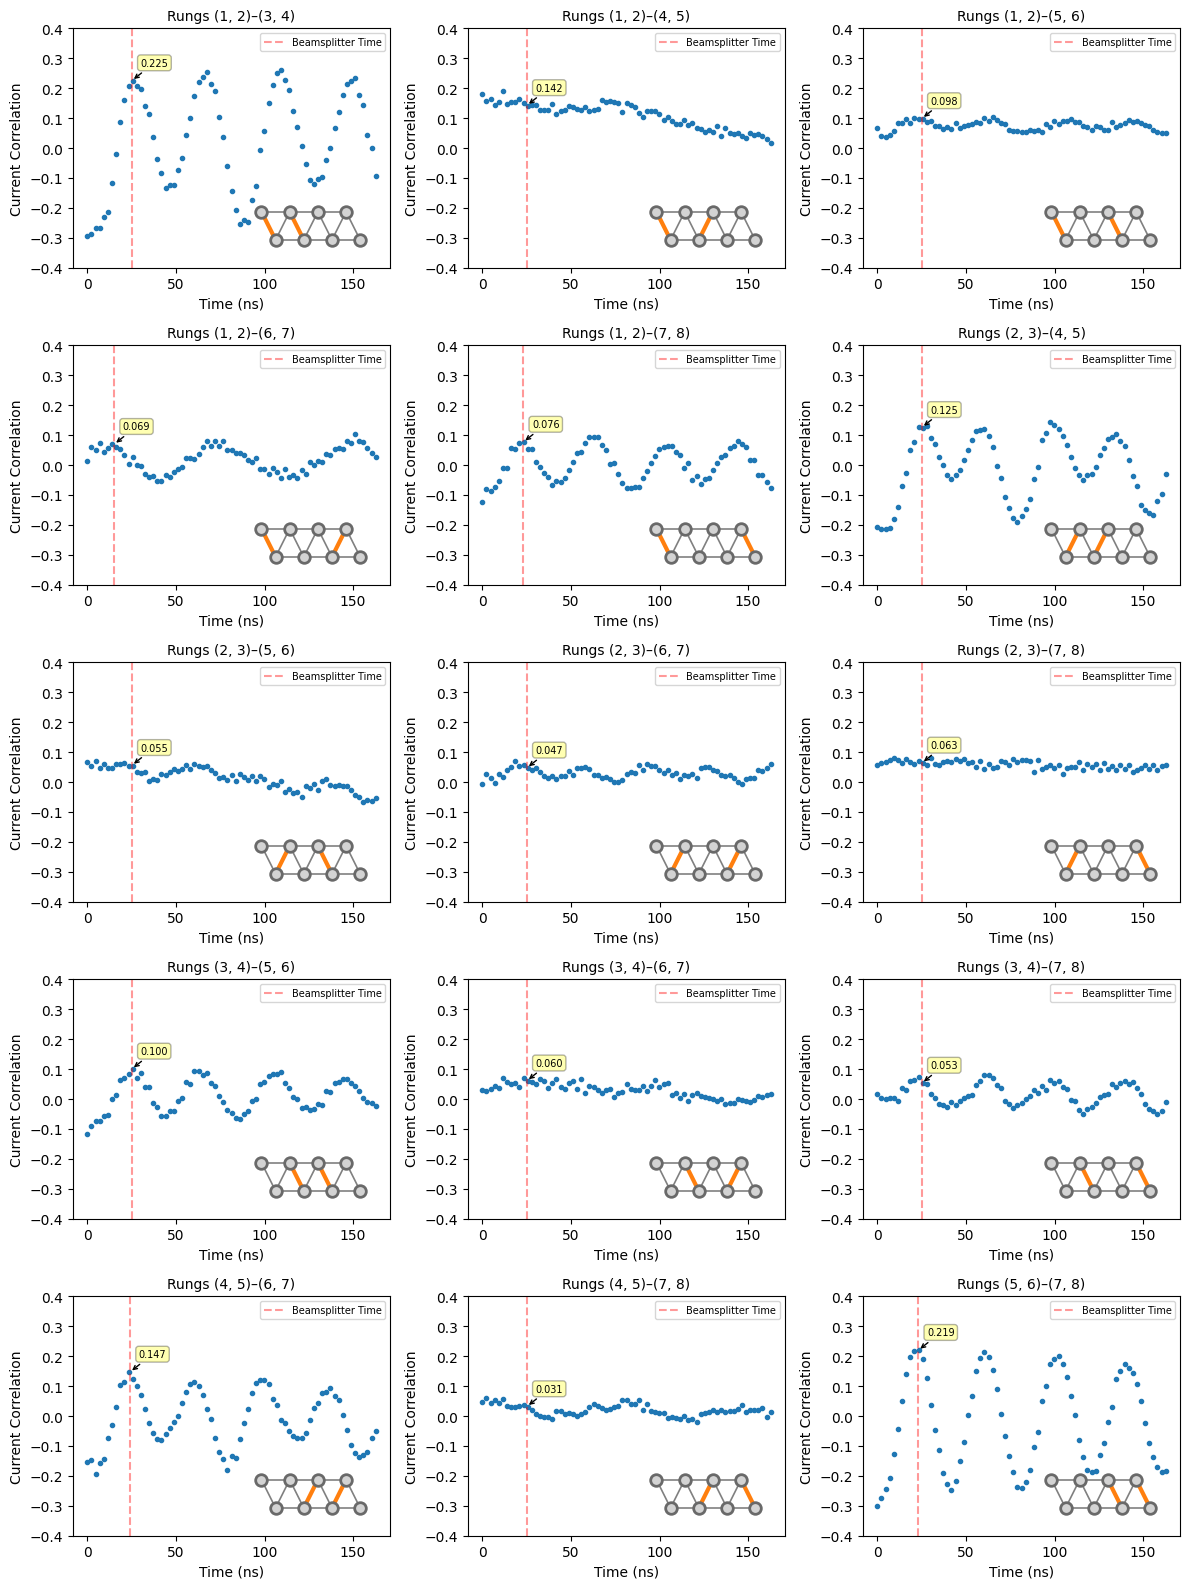

In [126]:
plot_correlation_grid_with_lattices(
    data=data,
    coupling_point=coupling_point,
    eigenstate=eigenstate,
    correlation_pairs=correlation_pairs,
    nrows=5,
    ncols=3
)


### 1.2 Plot Current Correlation by distance

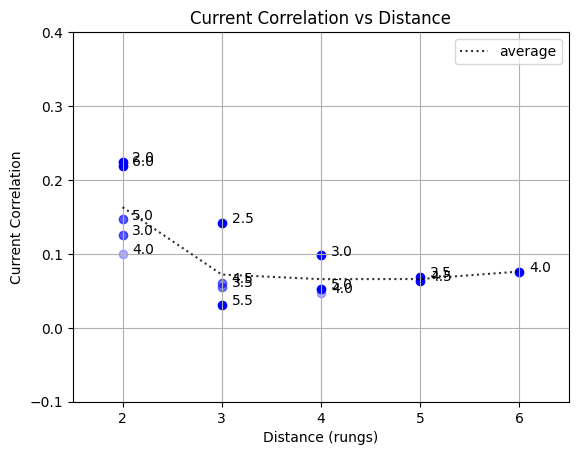

total chiral currnet: 0.44311400423386643


In [127]:
current_correlation_by_distance = {}


for correlation_pair in correlation_pairs:

    correlation_pair_data = data['data'][coupling_point][eigenstate][str(correlation_pair)]

    current_correlation_value = correlation_pair_data['current_correlation_value']

    distance = abs(min(correlation_pair[0]) - min(correlation_pair[1]))
    position = (min(correlation_pair[0]) + min(correlation_pair[1])) / 2

    if not distance in current_correlation_by_distance:
        current_correlation_by_distance[distance] = []
    
    current_correlation_by_distance[distance].append((current_correlation_value, position))


distances = []
current_correlation_averages = []

for distance in current_correlation_by_distance:
    distances.append(distance)
    temp_current_correlations = [corr_data[0] for corr_data in current_correlation_by_distance[distance]]
    current_correlation_averages.append(np.mean(temp_current_correlations))

# plot
for distance in current_correlation_by_distance:
    temp_current_correlations = [corr_data[0] for corr_data in current_correlation_by_distance[distance]]
    temp_positions = [corr_data[1] for corr_data in current_correlation_by_distance[distance]]
    
    def valley_normalize(arr, floor=0.3):
        arr = np.array(arr, dtype=float)
        med = np.median(arr)
        d = np.abs(arr - med)
        dmax = d.max()
        if dmax == 0:
            return np.ones_like(arr)
        normalized = d / dmax
        return floor + (1 - floor) * normalized
    
    alpha_values = valley_normalize(temp_positions)
    
    for current_corr_value, alpha_value, pos in zip(temp_current_correlations, alpha_values, temp_positions):
        plt.scatter([distance], current_corr_value, color='b', alpha=alpha_value)
        plt.annotate(f'{pos}', xy=(distance + 0.1, current_corr_value))

plt.plot(distances, current_correlation_averages, linestyle=':', color='black', alpha=0.8, label='average')

plt.xlabel('Distance (rungs)')
plt.xticks([2, 3, 4, 5, 6])
plt.ylabel('Current Correlation')
plt.legend()
plt.xlim(1.5, 6.5)
plt.ylim(-0.1, 0.4)

plt.grid()
plt.title('Current Correlation vs Distance')
plt.show()
print(f'total chiral currnet: {sum(current_correlation_averages)}')

### 1.3 Plot Correlations vs Position
and make each distance a different color

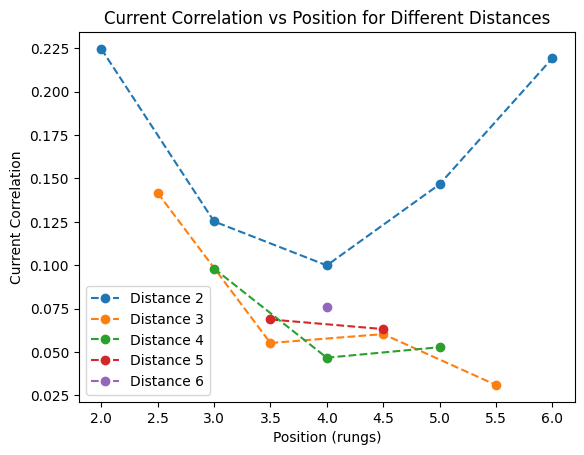

In [128]:
distance_to_current_correlation_vs_position = {}

for i in range(2,7):
    distance_to_current_correlation_vs_position[i] = {'correlation': [], 
                                                      'position': []}


for correlation_pair in correlation_pairs:

    correlation_pair_data = data['data'][coupling_point][eigenstate][str(correlation_pair)]

    current_correlation_value = correlation_pair_data['current_correlation_value']

    distance = abs(min(correlation_pair[0]) - min(correlation_pair[1]))

    position = (min(correlation_pair[0]) + min(correlation_pair[1])) / 2

    distance_to_current_correlation_vs_position[distance]['correlation'].append(current_correlation_value)
    distance_to_current_correlation_vs_position[distance]['position'].append(position)


for distance in distance_to_current_correlation_vs_position:
    plt.plot(distance_to_current_correlation_vs_position[distance]['position'],
                distance_to_current_correlation_vs_position[distance]['correlation'],
                marker='o', linestyle='--', label=f'Distance {distance}')
    
plt.xlabel('Position (rungs)')
plt.ylabel('Current Correlation')
plt.legend()
plt.title('Current Correlation vs Position for Different Distances')
plt.show()